[2026-07-13 21:17:52] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-13 21:17:52] [info     ] 评测区间网格                         days=242 first='2024-01-02 00:00:00' instruments=1206 last='2024-12-31 00:00:00'
[2026-07-13 21:17:52] [info     ] 加载训练 HF 面板                     end='2023-12-31 23:59:59' start='2022-01-01 00:00:00'
[2026-07-13 21:37:07] [info     ] GP 启动                          evolve_days=360 gens=40 pop=80 val_segs=2
[2026-07-13 21:37:07] [info     ] GP 代数                          best=0.3514 gen=1 mean=-287.2681 size=3 unique=79
[2026-07-13 21:37:50] [info     ] GP 代数                          best=0.5795 gen=5 mean=-212.2398 size=3 unique=80
[2026-07-13 21:38:40] [info     ] GP 代数                          best=0.6114 gen=10 mean=-162.2845 size=3 unique=76
[2026-07-13 21:39:32] [info     ] GP 代数                          best=0.6424 gen=15 mean=-137.2424 size=3 unique=79
[2026-07-13 21:40:21] [info     ] GP 代数                          best=0.6424 gen=2

时段,IC
2024-01-15~2024-02-08,-0.0131
2024-09-24~2024-10-08,0.0434

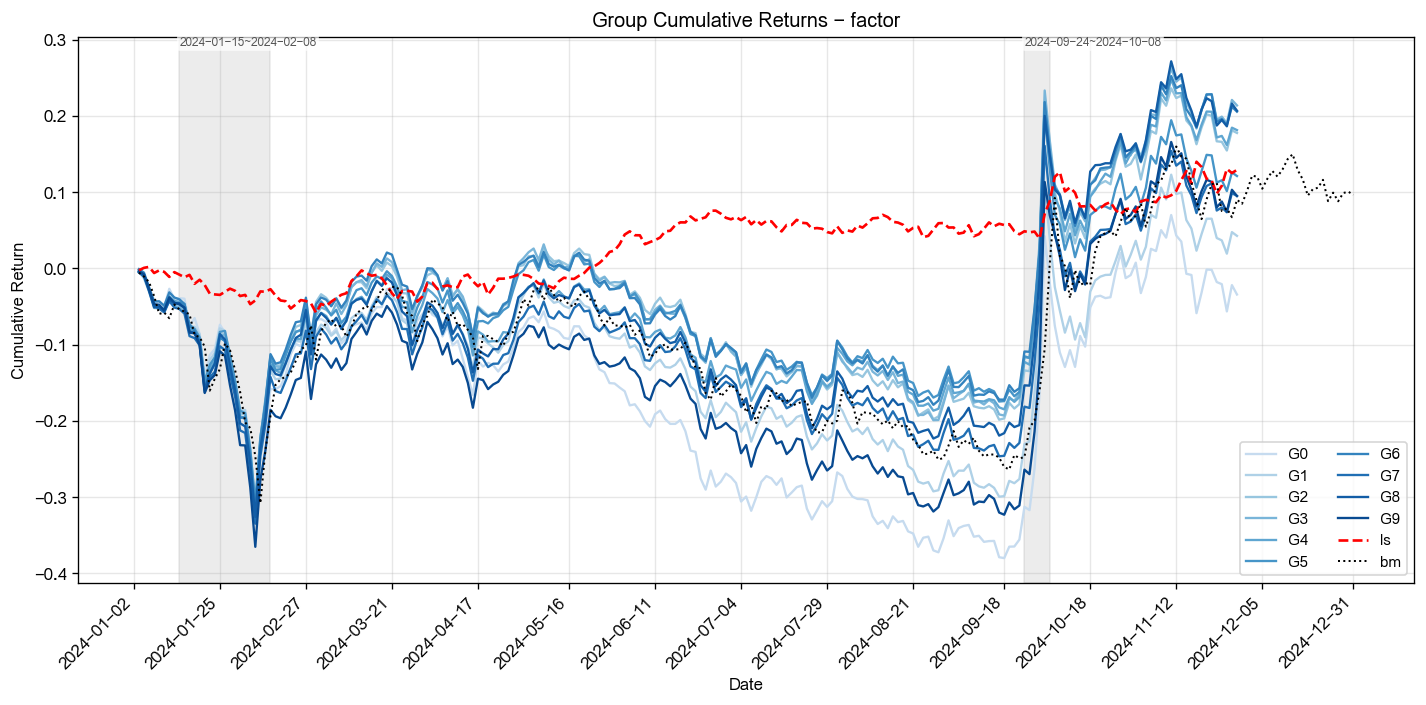
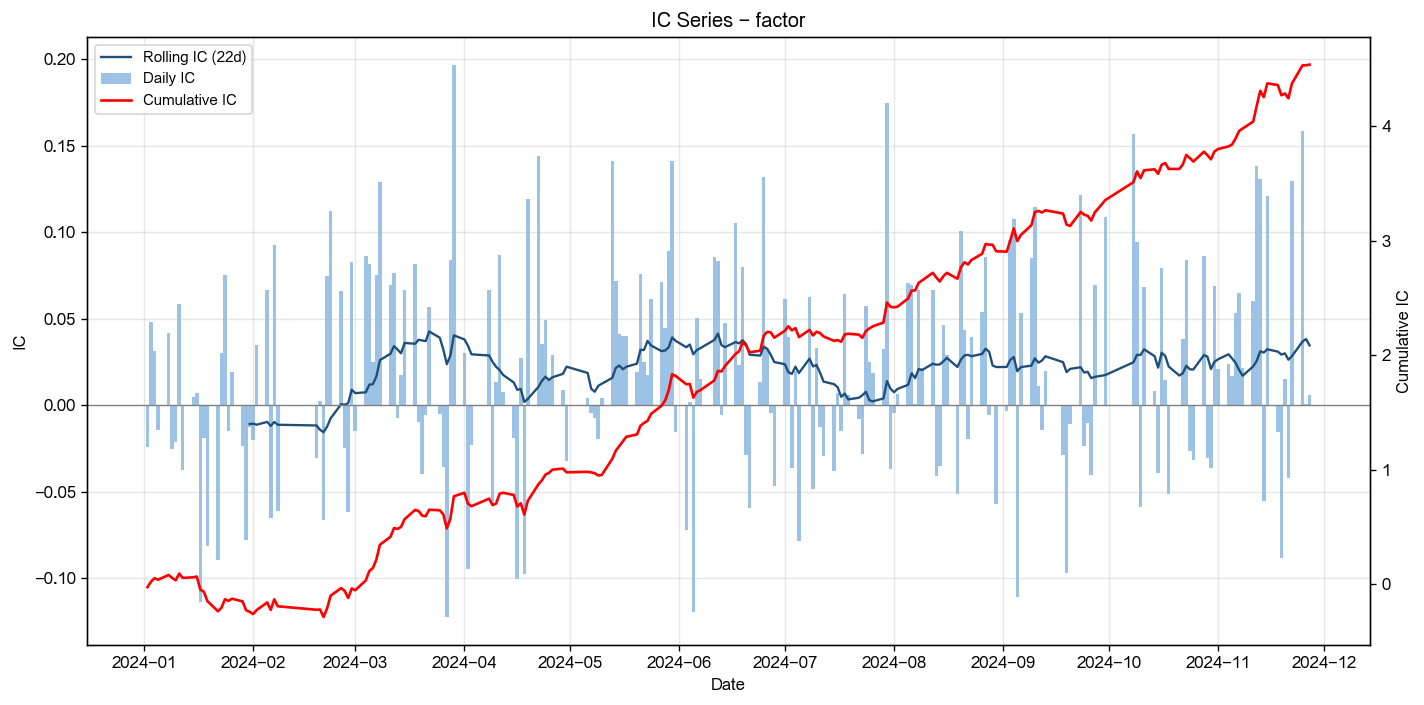
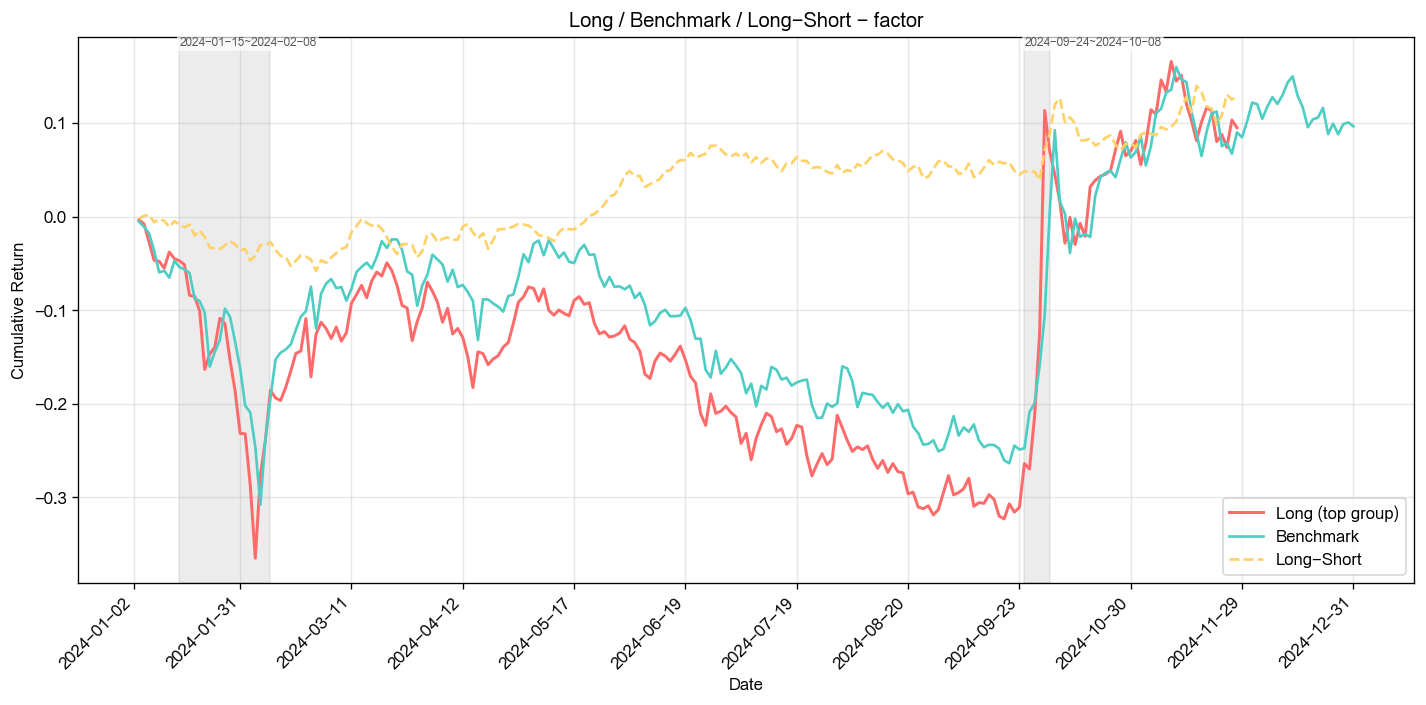
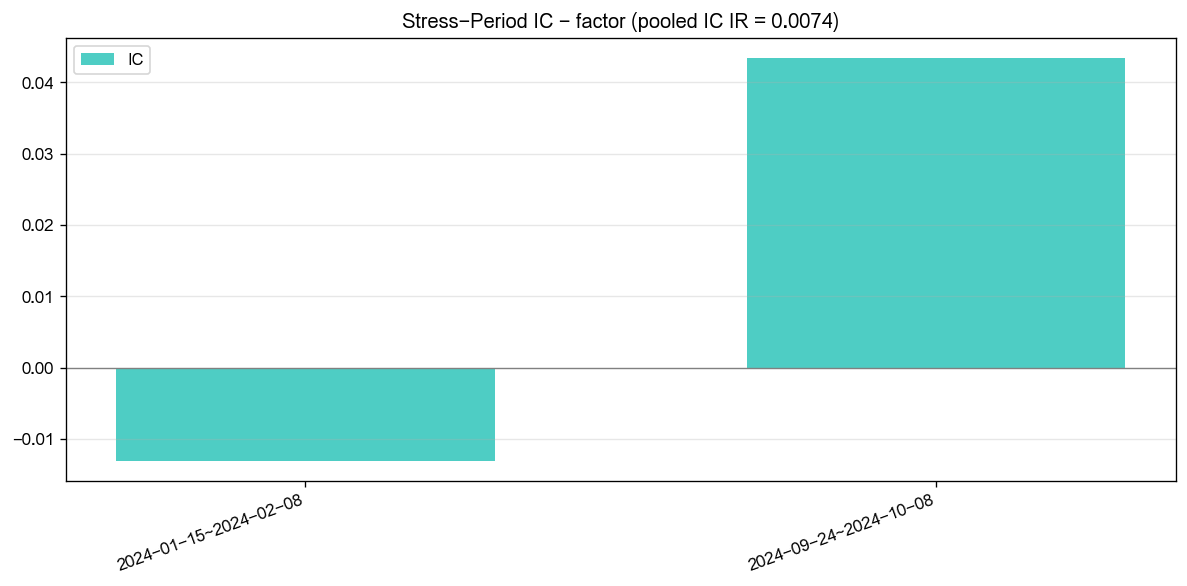
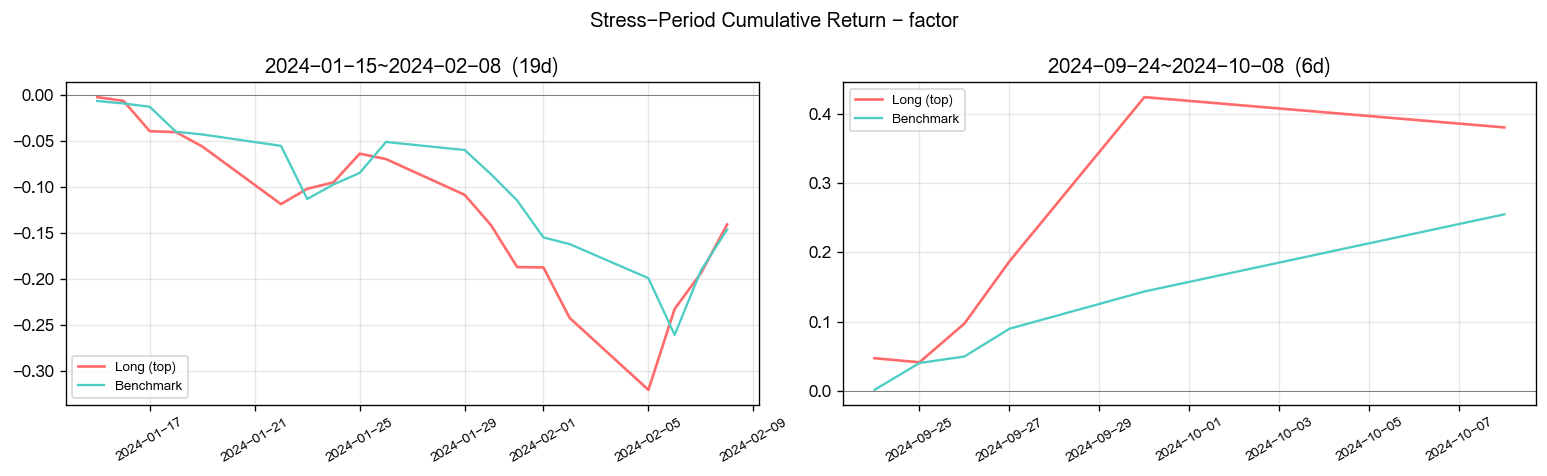

[2026-07-13 22:01:46] [info     ] ========== 因子池回归 ==========
[2026-07-13 22:01:46] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-13 22:01:47] [info     ] 获取收益率数据, 耗时: 1.1961 秒
[2026-07-13 22:01:49] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.781 秒
[2026-07-13 22:01:49] [info     ] 统计 回归结果, 耗时: 0.1151 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9022,0.0440,0.0231,1.0000
2,netflow_amount_rate_main,1.5427,0.0100,0.0065,1.0000
3,netflow_amount_main,1.4974,0.0250,0.0167,1.0000
4,pb,1.4963,0.0099,0.0066,0.9000
5,gross_profit_rate_ttm,1.4789,0.0067,0.0045,1.0000
6,net_profit_rate_ttm,1.4466,0.0039,0.0027,0.8000
7,amount,1.4109,0.0141,0.0100,0.9000
8,volume,1.3873,0.0142,0.0102,1.0000
9,bias_20,1.3699,0.0280,0.0204,0.9000
10,pe_ttm,1.3254,0.0029,0.0022,0.9000

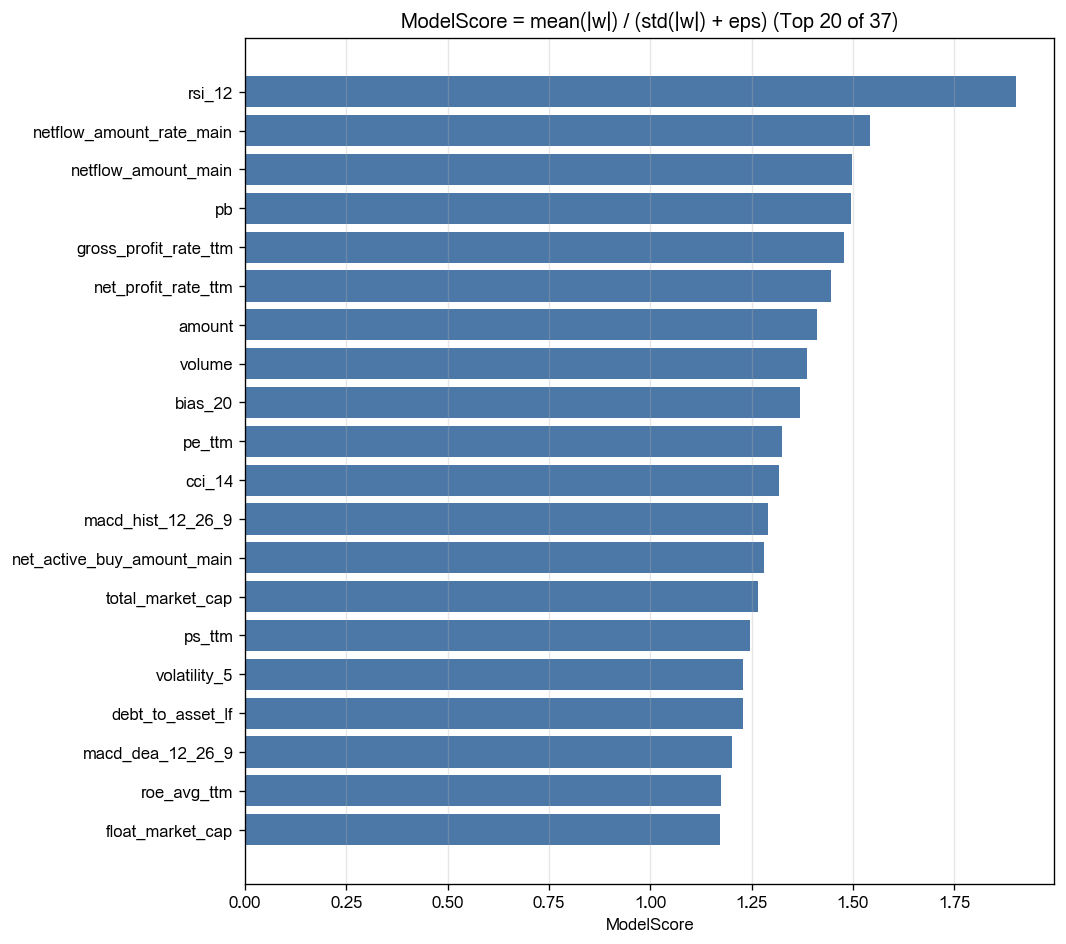
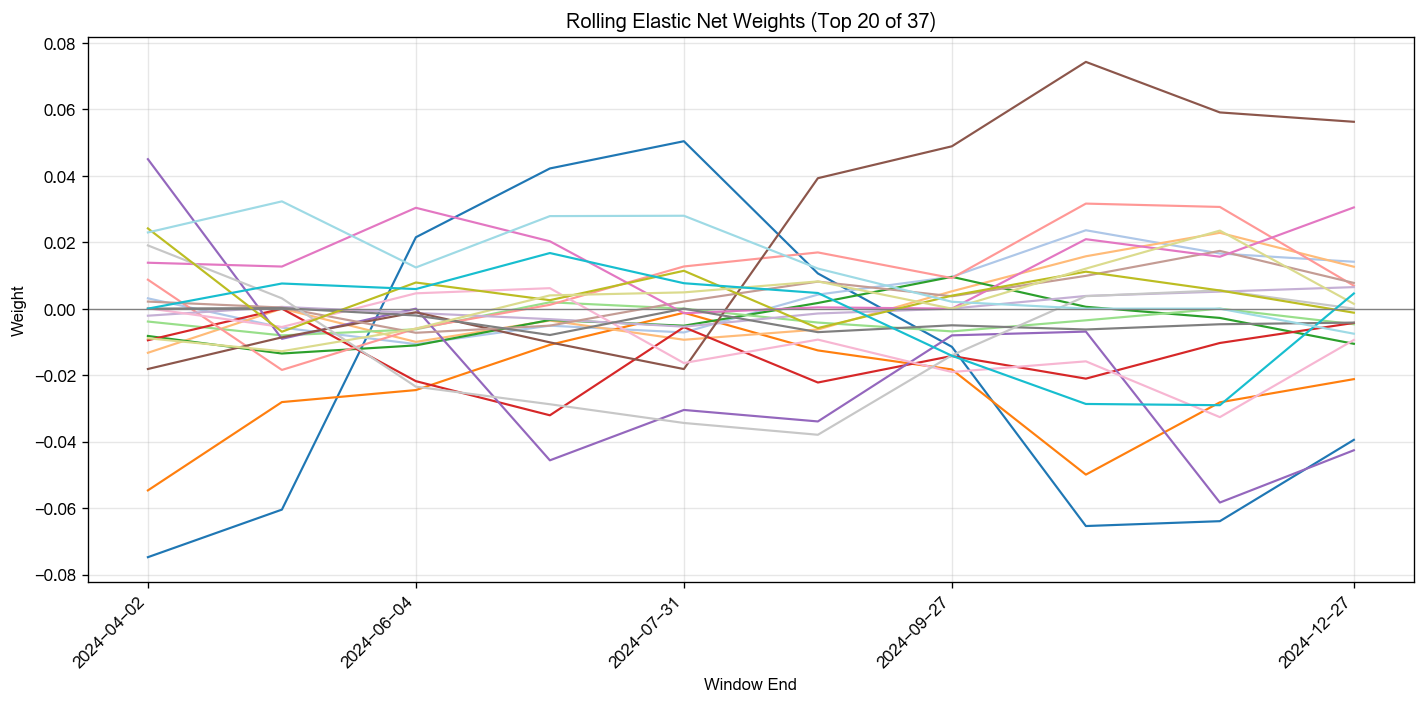
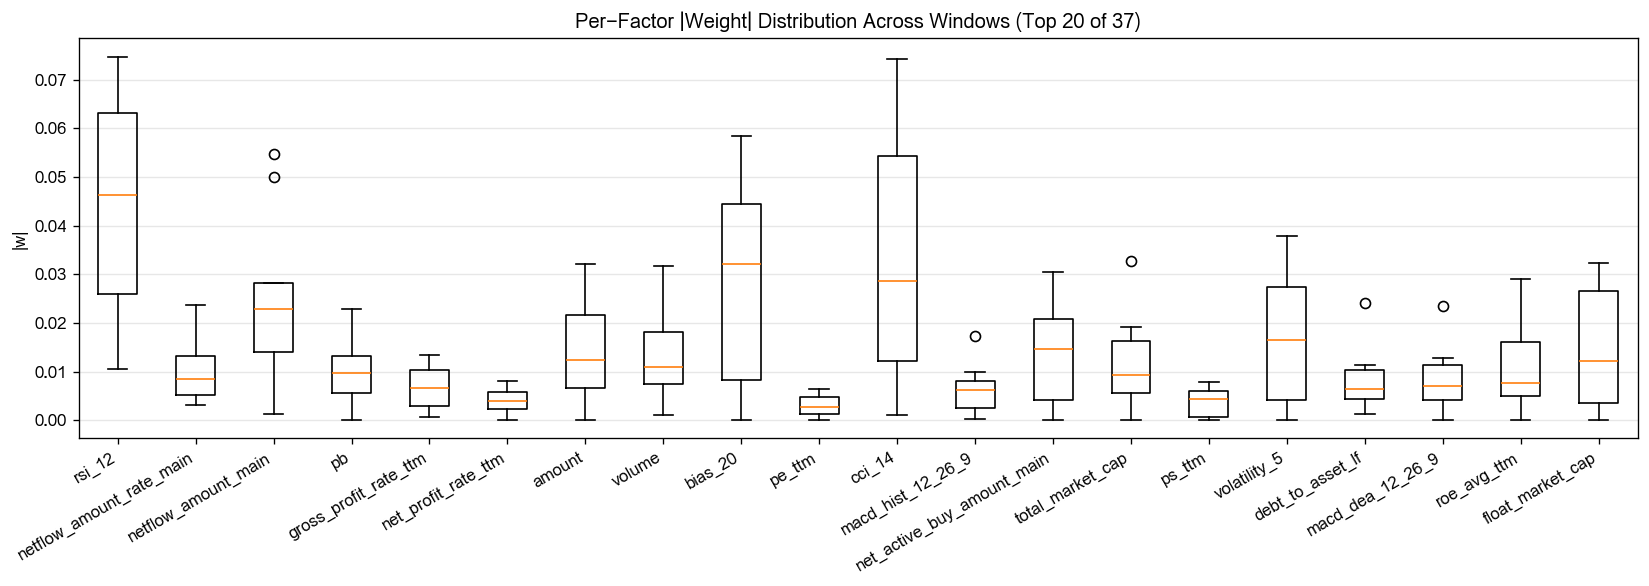
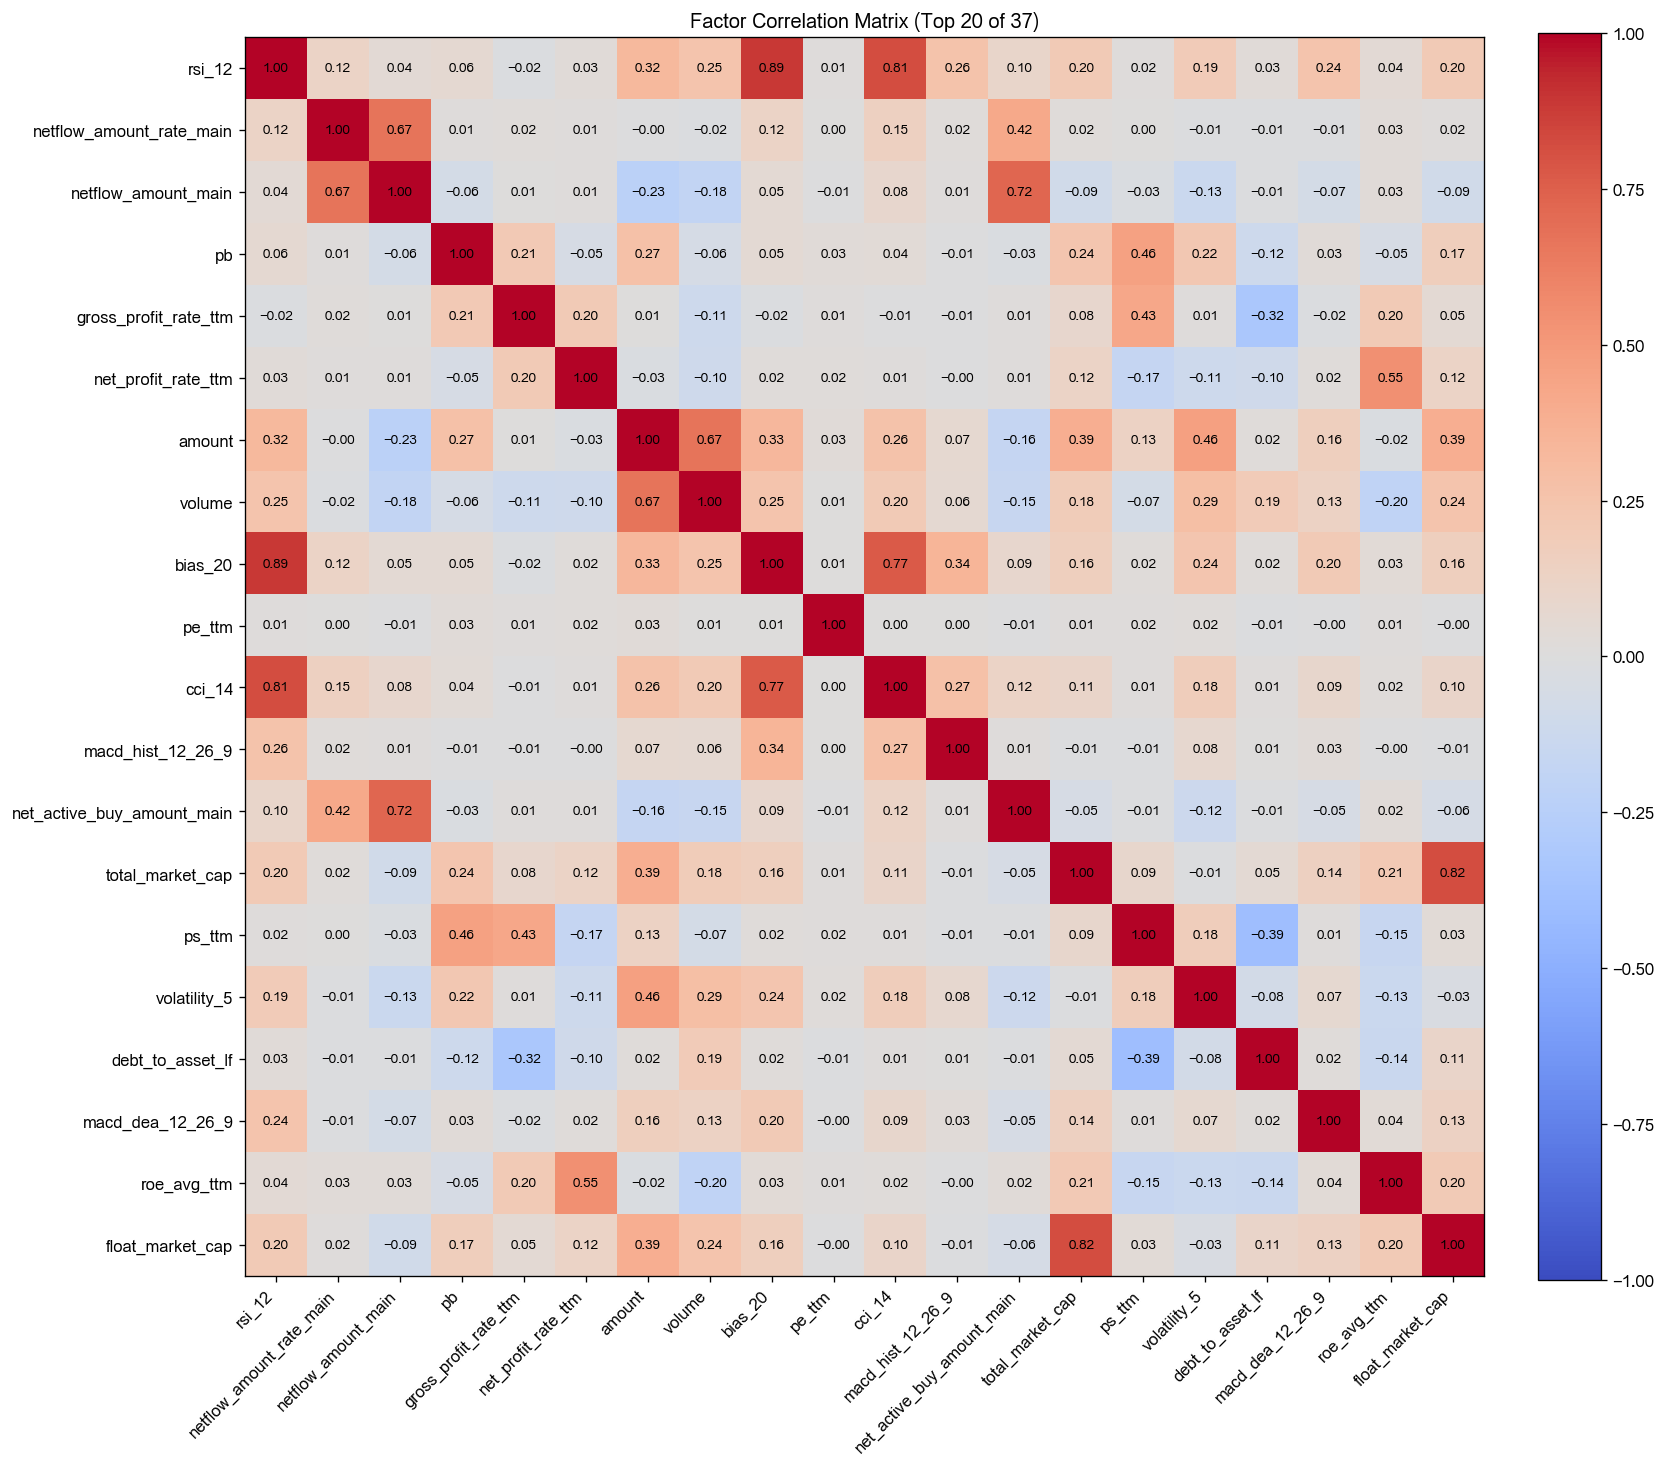

[2026-07-13 22:01:52] [warning  ] 返回的Outputs实例(size=35317948) 大于 64K, 将不会被缓存
[2026-07-13 22:01:52] [info     ] bigalpha_eval.v4 运行完成 [94.391s].


In [1]:
"""
BigAlpha 2026 · AI 因子挖掘赛道
高频盘口聚合 + GP 因子挖掘 + LightGBM 集成
================================================================

流水线:
    [bar1m 1分钟盘口] →SQL聚合→ [日频日内特征面板 ~50列] →GP搜索→ [Top-10弱因子]
                                             ↓                          ↓
                                      [面板补充factorlib日频]    →[LightGBM集成]→ 最终因子

防数据泄漏:
    GP 进化 + LightGBM 训练都只用写死的 TRAIN 区间 (2022-2023);
    平台注入的 start_date/end_date 仅用于样本外预测。
"""

import time
import random
import hashlib
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import structlog

logger = structlog.get_logger()


# =====================================================================
# 全局配置
# =====================================================================

RANDOM_SEED = 2026

# 训练区间 (写死, 不随平台入参变化 —— 防止在测试集上训练)
TRAIN_START = "2022-01-01 00:00:00"
TRAIN_END   = "2023-12-31 23:59:59"

# 防过拟合: 在 TRAIN 区间内做时间分离的多段验证
EVOLVE_END = "2023-06-30 23:59:59"
VAL_SEGMENTS = [
    ("2023-07-01 00:00:00", "2023-09-30 23:59:59"),
    ("2023-10-01 00:00:00", "2023-12-31 23:59:59"),
]

LABEL_HORIZON = 5

# 高频日内特征清单 (~50列)
HF_FEATURES = [
    "ofi_mean", "ofi_std", "ofi_last", "ofi_extreme", "ofi_m2",
    "wimb_mean", "wimb_std", "wimb_last", "wimb_m2", "wimb_m3",
    "rspread_mean", "rspread_max", "rspread_last",
    "depth_mean", "depth_std", "depth_last",
    "ret_mean", "ret_std", "ret_m2", "ret_m3", "ret_m4",
    "ret_p80", "ret_min", "ret_max",
    "vol_mean", "vol_std", "vol_last", "vol_max", "vol_m2",
    "amt_mean", "amt_last", "amt_m2",
    "deal_mean", "deal_std",
    "close_ret", "hl_range_max", "hl_range_mean", "mid_chg",
    "vp_corr", "spread_vol_corr", "imb_ret_corr", "depth_ret_corr",
    "amihud", "realized_vol", "kyle_lambda", "pressure_ratio", "ofi_abs_mean",
    "wimb_ret", "ofi_vol", "spread_imb",
]

TERMINAL_FIELDS = HF_FEATURES
WINDOWS = [3, 5, 10, 20, 30, 60]
CONST_POOL = [-2.0, -1.0, -0.5, 0.5, 1.0, 2.0]

# GP 超参
POP_SIZE        = 80
N_GENERATIONS   = 40
TOURNAMENT_K    = 5
ELITE_N         = 2
MAX_DEPTH       = 6
INIT_MAX_DEPTH  = 4
SUBTREE_MUT_DEPTH = 3
P_CROSSOVER     = 0.7
P_MUTATE        = 0.4
HALL_OF_FAME    = 12
TOP_K_ENSEMBLE  = 10
IMMIGRANT_N     = 8

MIN_STOCKS_PER_DAY = 200
MIN_COVERAGE       = 0.60
TRIVIAL_PENALTY    = 0.5

SAMPLE_INSTRUMENTS = 400
SAMPLE_DAYS        = 500
USE_FLOAT32        = True

# 时序算子 warmup: 向前多取的日历日数 (ts_*(窗口最大60, 可嵌套);
# 不足部分由 LightGBM 原生缺失值处理 + 前向填充兜底)
WARMUP_DAYS        = 250

_EPS = 1e-8


# =====================================================================
# 1. 原语注册表与表达式树
# =====================================================================

class Node:
    __slots__ = ("op", "children", "args")

    def __init__(self, op: str, children: Tuple["Node", ...] = (), args: tuple = ()):
        self.op = op
        self.children = list(children)
        self.args = tuple(args)

    def to_str(self) -> str:
        a = "" if not self.args else "(" + ",".join(str(x) for x in self.args) + ")"
        if not self.children:
            return f"{self.op}{a}"
        return f"{self.op}{a}(" + ",".join(c.to_str() for c in self.children) + ")"

    def hash(self) -> str:
        return hashlib.md5(self.to_str().encode()).hexdigest()

    def size(self) -> int:
        return 1 + sum(c.size() for c in self.children)

    def depth(self) -> int:
        return 1 + max((c.depth() for c in self.children), default=0)

    def clone(self) -> "Node":
        return Node(self.op, tuple(c.clone() for c in self.children), self.args)

    def __repr__(self):
        return self.to_str()


PRIMITIVES: Dict[str, Tuple[str, int]] = {
    "neg":       ("unary", 1),
    "abs":       ("unary", 1),
    "log":       ("unary", 1),
    "sign":      ("unary", 1),
    "sigmoid":   ("unary", 1),
    "tanh":      ("unary", 1),
    "cs_rank":   ("unary", 1),
    "cs_zscore": ("unary", 1),
    "cs_indneutralize": ("unary", 1),
    "add": ("binary", 2),
    "sub": ("binary", 2),
    "mul": ("binary", 2),
    "div": ("binary", 2),
    "min": ("binary", 2),
    "max": ("binary", 2),
    "ts_mean":  ("ts1", 1),
    "ts_std":   ("ts1", 1),
    "ts_max":   ("ts1", 1),
    "ts_min":   ("ts1", 1),
    "ts_sum":   ("ts1", 1),
    "ts_delta": ("ts1", 1),
    "ts_lag":   ("ts1", 1),
    "ts_rank":  ("ts1", 1),
    "ts_return":("ts1", 1),
    "ts_corr":  ("ts2", 2),
}

UNARY_OPS  = [o for o, (k, _) in PRIMITIVES.items() if k == "unary"]
BINARY_OPS = [o for o, (k, _) in PRIMITIVES.items() if k == "binary"]
TS1_OPS    = [o for o, (k, _) in PRIMITIVES.items() if k == "ts1"]
TS2_OPS    = [o for o, (k, _) in PRIMITIVES.items() if k == "ts2"]


def _rand_window() -> int:
    return random.choice(WINDOWS)


def _rand_terminal() -> Node:
    if random.random() < 0.8:
        return Node("field", args=(random.choice(TERMINAL_FIELDS),))
    return Node("const", args=(random.choice(CONST_POOL),))


def _rand_function(allow_ts: bool = True) -> str:
    pool = UNARY_OPS + BINARY_OPS
    if allow_ts:
        pool = pool + TS1_OPS + TS2_OPS
    return random.choice(pool)


def random_tree(max_depth: int, full: bool = False) -> Node:
    if max_depth <= 1 or (not full and random.random() < 0.3):
        return _rand_terminal()
    op = _rand_function(allow_ts=True)
    kind, arity = PRIMITIVES[op]
    if kind == "unary":
        children = (random_tree(max_depth - 1, full),)
    elif kind == "binary":
        children = (random_tree(max_depth - 1, full), random_tree(max_depth - 1, full))
    elif kind == "ts1":
        children = (random_tree(max_depth - 1, full),)
        return Node(op, children, (_rand_window(),))
    else:
        children = (random_tree(max_depth - 1, full), random_tree(max_depth - 1, full))
        return Node(op, children, (_rand_window(),))
    return Node(op, children)


def init_population(n: int) -> List[Node]:
    pop = []
    for i in range(n):
        d = 2 + (i % max(1, INIT_MAX_DEPTH - 1))
        full = (i % 2 == 0)
        pop.append(random_tree(d, full=full))
    return pop


# =====================================================================
# 2. 高频特征聚合层: bar1m → 日频日内特征面板 (~50列)
# =====================================================================

def _pivot_panel(df: pd.DataFrame, fields: List[str]) -> Dict[str, pd.DataFrame]:
    """长表 -> {field: date×instrument 矩阵}, 统一索引/列对齐。"""
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    df = df.dropna(subset=["instrument"])
    df["instrument"] = df["instrument"].astype(str)

    common_idx = sorted(df["date"].unique())
    common_cols = sorted(df["instrument"].unique())

    panel = {}
    for f in fields:
        if f not in df.columns:
            continue
        p = df.pivot_table(index="date", columns="instrument", values=f)
        p = p.reindex(index=common_idx, columns=common_cols)
        panel[f] = p
    panel["__base__"] = pd.DataFrame(0.0, index=common_idx, columns=common_cols)
    return panel


def build_hf_feature_panel(datasources: dict, sd: str, ed: str,
                           warmup_days: int = 0) -> Dict[str, pd.DataFrame]:
    """
    SQL 聚合 bar1m → 日频日内特征面板 (~50列)。

    参数:
        sd, ed: 目标输出区间 [sd, ed] (含)。
        warmup_days: 向前多取的日历日数, 用于时序算子的 warmup 历史。
                     取数区间变为 [sd - warmup_days, ed], 但只用于算特征不外泄。

    返回: dict[field_name -> DataFrame(date×instrument)], 含 'close' 和 '__base__'。
    """
    import dai

    bar1m = datasources["bar1m"]

    # 计算实际取数区间: 向前多取 warmup_days 个日历日 (约 WARMUP_DAYS*0.7 个交易日)
    sd_dt = pd.to_datetime(sd)
    fetch_start = (sd_dt - pd.Timedelta(days=warmup_days)).strftime("%Y-%m-%d %H:%M:%S")

    sql = f"""
    WITH cte_bar1m AS (
        SELECT
            date, instrument,
            strftime(date, '%Y-%m-%d') as trading_day,
            (ask_price1 + bid_price1) / 2.0 as mid_price,
            -- 加权5档买方量 (BIGINT 防溢出)
            (COALESCE(bid_volume1, 0)::BIGINT * 1.0 +
             COALESCE(bid_volume2, 0)::BIGINT * EXP(-0.3) +
             COALESCE(bid_volume3, 0)::BIGINT * EXP(-0.6) +
             COALESCE(bid_volume4, 0)::BIGINT * EXP(-0.9) +
             COALESCE(bid_volume5, 0)::BIGINT * EXP(-1.2)) as wbid,
            (COALESCE(ask_volume1, 0)::BIGINT * 1.0 +
             COALESCE(ask_volume2, 0)::BIGINT * EXP(-0.3) +
             COALESCE(ask_volume3, 0)::BIGINT * EXP(-0.6) +
             COALESCE(ask_volume4, 0)::BIGINT * EXP(-0.9) +
             COALESCE(ask_volume5, 0)::BIGINT * EXP(-1.2)) as wask,
            (COALESCE(bid_volume1, 0) + COALESCE(bid_volume2, 0) + COALESCE(bid_volume3, 0)) as tbid3,
            (COALESCE(ask_volume1, 0) + COALESCE(ask_volume2, 0) + COALESCE(ask_volume3, 0)) as task3,
            (ask_price1 - bid_price1) / ((ask_price1 + bid_price1) / 2.0 + 1e-8) as rspread,
            COALESCE(bid_volume1, 0)::BIGINT - COALESCE(ask_volume1, 0)::BIGINT as ofi_raw,
            close, volume, amount, high, low, open, deal_number,
            high - low as hl_range
        FROM {bar1m}
        WHERE ask_price1 > 0 AND bid_price1 > 0
          AND date >= '{fetch_start}' AND date <= '{ed}'
    ),
    cte_derived AS (
        SELECT
            *,
            (wbid - wask) / (wbid + wask + 1e-8) as wimb,
            (tbid3 - task3) / (tbid3 + task3 + 1e-8) as depth_ratio,
            lag(mid_price, 1) OVER (PARTITION BY instrument, trading_day ORDER BY date) as prev_mid,
            lag(volume, 1) OVER (PARTITION BY instrument, trading_day ORDER BY date) as prev_vol,
            lag(ofi_raw, 1) OVER (PARTITION BY instrument, trading_day ORDER BY date) as prev_ofi
        FROM cte_bar1m
    ),
    cte_rolling AS (
        SELECT
            *,
            CASE WHEN prev_mid > 0 THEN mid_price / prev_mid - 1.0 ELSE NULL END as ret,
            CASE WHEN prev_vol > 0 THEN volume::DOUBLE / prev_vol - 1.0 ELSE NULL END as vol_chg,
            ofi_raw - prev_ofi as ofi
        FROM cte_derived
    ),
    cte_daily AS (
        SELECT
            CAST(trading_day AS DATETIME) as date,
            instrument,
            -- OFI (5)
            avg(ofi) as ofi_mean,
            nanstd(ofi) as ofi_std,
            last(ofi order by date) as ofi_last,
            avg(CASE WHEN abs(ofi) > 0.7 THEN 1.0 ELSE 0.0 END) as ofi_extreme,
            avg(ofi * ofi) as ofi_m2,
            -- WImb (5)
            avg(wimb) as wimb_mean,
            nanstd(wimb) as wimb_std,
            last(wimb order by date) as wimb_last,
            avg(wimb * wimb) as wimb_m2,
            avg(wimb * wimb * wimb) as wimb_m3,
            -- RSpread (3)
            avg(rspread) as rspread_mean,
            max(rspread) as rspread_max,
            last(rspread order by date) as rspread_last,
            -- Depth (3)
            avg(depth_ratio) as depth_mean,
            nanstd(depth_ratio) as depth_std,
            last(depth_ratio order by date) as depth_last,
            -- Returns (8)
            avg(ret) as ret_mean,
            nanstd(ret) as ret_std,
            avg(ret * ret) as ret_m2,
            avg(ret * ret * ret) as ret_m3,
            avg(ret * ret * ret * ret) as ret_m4,
            quantile(ret, 0.8) as ret_p80,
            min(ret) as ret_min,
            max(ret) as ret_max,
            -- Volume (5)
            avg(volume::DOUBLE) as vol_mean,
            nanstd(volume::DOUBLE) as vol_std,
            last(volume order by date) as vol_last,
            max(volume) as vol_max,
            avg(volume::DOUBLE * volume::DOUBLE) as vol_m2,
            -- Amount (3)
            avg(amount) as amt_mean,
            last(amount order by date) as amt_last,
            avg(amount * amount) as amt_m2,
            -- Deal Number (2)
            avg(deal_number::DOUBLE) as deal_mean,
            nanstd(deal_number::DOUBLE) as deal_std,
            -- Price (4)
            last(close order by date) / (first(close order by date) + 1e-8) - 1.0 as close_ret,
            max(hl_range) as hl_range_max,
            avg(hl_range) as hl_range_mean,
            last(mid_price order by date) / (first(mid_price order by date) + 1e-8) - 1.0 as mid_chg,
            -- Correlations (4)
            corr(ret, vol_chg) as vp_corr,
            corr(rspread, volume::DOUBLE) as spread_vol_corr,
            corr(wimb, ret) as imb_ret_corr,
            corr(depth_ratio, ret) as depth_ret_corr,
            -- Microstructure (5)
            sum(abs(ret)) / (sum(volume::DOUBLE) + 1e-8) as amihud,
            sum(ret * ret) as realized_vol,
            avg(rspread * volume::DOUBLE) as kyle_lambda,
            last(wbid order by date) / (last(wask order by date) + 1e-8) as pressure_ratio,
            avg(abs(ofi)) as ofi_abs_mean,
            -- Cross (3)
            avg(wimb * ret) as wimb_ret,
            avg(ofi * volume::DOUBLE) as ofi_vol,
            avg(rspread * wimb) as spread_imb,
            -- Close for label
            last(close order by date) as close
        FROM cte_rolling
        WHERE ret IS NOT NULL
        GROUP BY instrument, trading_day
        HAVING count(*) > 10
    )
    SELECT * FROM cte_daily
    """

    df = dai.query(sql, filters={'date': [fetch_start, ed]}, compression=True).df()
    panel = _pivot_panel(df, HF_FEATURES + ["close"])

    # 加载 float_market_cap 用于 cs_indneutralize
    try:
        mc_df = dai.query(
            "SELECT date, instrument, float_market_cap FROM bigalpha_2026_factorlib",
            filters={'date': [fetch_start, ed]},
        ).df()
        mc_panel = _pivot_panel(mc_df, ["float_market_cap"])
        if "float_market_cap" in mc_panel:
            panel["float_market_cap"] = mc_panel["float_market_cap"]
    except Exception:
        pass

    return panel


# =====================================================================
# 3. 表达式求值
# =====================================================================

def _safe(x: pd.DataFrame) -> pd.DataFrame:
    return x.replace([np.inf, -np.inf], np.nan)


def eval_node(node: Node, panel: Dict, cache: Optional[Dict[str, pd.DataFrame]] = None) -> pd.DataFrame:
    if cache is not None:
        key = node.hash()
        if key in cache:
            return cache[key]

    op = node.op

    if op == "field":
        out = panel.get(node.args[0], panel["__base__"]).copy()
    elif op == "const":
        base = panel["__base__"]
        out = pd.DataFrame(node.args[0], index=base.index, columns=base.columns)
    elif op == "neg":
        out = -eval_node(node.children[0], panel, cache)
    elif op == "abs":
        out = eval_node(node.children[0], panel, cache).abs()
    elif op == "log":
        out = np.log(eval_node(node.children[0], panel, cache).abs() + _EPS)
    elif op == "sign":
        out = np.sign(eval_node(node.children[0], panel, cache))
    elif op == "sigmoid":
        x = eval_node(node.children[0], panel, cache)
        out = 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))
    elif op == "tanh":
        out = np.tanh(np.clip(eval_node(node.children[0], panel, cache), -30, 30))
    elif op == "cs_rank":
        out = eval_node(node.children[0], panel, cache).rank(axis=1, pct=True)
    elif op == "cs_zscore":
        x = eval_node(node.children[0], panel, cache)
        m = x.mean(axis=1, skipna=True)
        s = x.std(axis=1, skipna=True).replace(0, np.nan)
        out = x.sub(m, axis=0).div(s, axis=0)
    elif op == "cs_indneutralize":
        x = eval_node(node.children[0], panel, cache)
        if "float_market_cap" in panel:
            mc = np.log1p(panel["float_market_cap"])
            out = x.rank(axis=1, pct=True) - mc.rank(axis=1, pct=True)
        else:
            out = x.rank(axis=1, pct=True) - 0.5
    elif op in ("add", "sub", "mul", "min", "max"):
        a = eval_node(node.children[0], panel, cache)
        b = eval_node(node.children[1], panel, cache)
        if op == "add": out = a + b
        elif op == "sub": out = a - b
        elif op == "mul": out = a * b
        elif op == "min": out = np.minimum(a, b)
        else: out = np.maximum(a, b)
    elif op == "div":
        a = eval_node(node.children[0], panel, cache)
        b = eval_node(node.children[1], panel, cache).replace(0, np.nan)
        out = a / b
    elif op in TS1_OPS:
        x = eval_node(node.children[0], panel, cache)
        w = int(node.args[0])
        if op == "ts_mean":   out = x.rolling(w, min_periods=2).mean()
        elif op == "ts_std":  out = x.rolling(w, min_periods=2).std()
        elif op == "ts_max":  out = x.rolling(w, min_periods=2).max()
        elif op == "ts_min":  out = x.rolling(w, min_periods=2).min()
        elif op == "ts_sum":  out = x.rolling(w, min_periods=2).sum()
        elif op == "ts_delta":out = x - x.shift(w)
        elif op == "ts_lag":  out = x.shift(w)
        elif op == "ts_rank": out = x.rolling(w, min_periods=2).rank(pct=True)
        elif op == "ts_return": out = x / x.shift(w) - 1.0
    elif op == "ts_corr":
        a = eval_node(node.children[0], panel, cache)
        b = eval_node(node.children[1], panel, cache)
        w = int(node.args[0])
        out = a.rolling(w, min_periods=5).corr(b)
    else:
        raise ValueError(f"未知原语: {op}")

    out = _safe(out)
    if cache is not None:
        cache[key] = out
    return out


# =====================================================================
# 4. 适应度: 日频 Rank-IC / ICIR
# =====================================================================

def _daily_rank_ic(F: pd.DataFrame, L: pd.DataFrame, min_stocks: int) -> pd.Series:
    valid = F.notna() & L.notna()
    n = valid.sum(axis=1)
    Fr = F.rank(axis=1, pct=False).where(valid)
    Lr = L.rank(axis=1, pct=False).where(valid)
    mF = Fr.mean(axis=1, skipna=True)
    mL = Lr.mean(axis=1, skipna=True)
    dF = Fr.sub(mF, axis=0)
    dL = Lr.sub(mL, axis=0)
    cov = (dF * dL).sum(axis=1, skipna=True)
    sF = (dF * dF).sum(axis=1, skipna=True).pow(0.5)
    sL = (dL * dL).sum(axis=1, skipna=True).pow(0.5)
    ic = cov / (sF * sL + _EPS)
    return ic.where(n >= min_stocks)


def _factor_coverage(F: pd.DataFrame, label: pd.DataFrame) -> float:
    valid_label = label.notna()
    denom = valid_label.sum(axis=1).replace(0, np.nan)
    cov_per_day = F.notna().where(valid_label).sum(axis=1) / denom
    return float(cov_per_day.mean()) if not cov_per_day.empty else 0.0


def fitness(node: Node, panel: Dict, label: pd.DataFrame,
            cache: Optional[Dict] = None) -> Tuple[float, dict]:
    try:
        F = eval_node(node, panel, cache)
    except Exception:
        return -999.0, {"mean_ic": 0.0, "ic_ir": 0.0, "cov": 0.0, "size": node.size()}

    F = F.reindex_like(label)
    ic = _daily_rank_ic(F, label, MIN_STOCKS_PER_DAY).dropna()
    if ic.empty:
        return -999.0, {"mean_ic": 0.0, "ic_ir": 0.0, "cov": 0.0, "size": node.size()}

    mean_ic = float(ic.mean())
    ic_ir = float(ic.mean() / (ic.std() + _EPS))
    cov = _factor_coverage(F, label)
    size = node.size()

    if cov < MIN_COVERAGE or abs(mean_ic) < 2e-4 or not np.isfinite(ic_ir):
        return -999.0, {"mean_ic": mean_ic, "ic_ir": ic_ir, "cov": cov, "size": size}

    fit = ic_ir / (1.0 + 0.05 * size)
    if size <= 2:
        fit *= (1.0 - TRIVIAL_PENALTY)
    return fit, {"mean_ic": mean_ic, "ic_ir": ic_ir, "cov": cov, "size": size}


# =====================================================================
# 5. 遗传算子
# =====================================================================

def _collect(node: Node, parent: Optional[Node], idx: int) -> List[Tuple[Node, Optional[Node], int]]:
    out = [(node, parent, idx)]
    for i, c in enumerate(node.children):
        out.extend(_collect(c, node, i))
    return out


def tournament_select(scored: List[Tuple[Node, float]], k: int) -> Node:
    contenders = random.sample(scored, min(k, len(scored)))
    winner = max(contenders, key=lambda t: t[1])
    return winner[0].clone()


def crossover(a: Node, b: Node) -> Tuple[Node, Node]:
    a2 = a.clone()
    b2 = b.clone()
    na, pa, ia = random.choice(_collect(a2, None, -1))
    nb, pb, ib = random.choice(_collect(b2, None, -1))
    if pa is None:
        a2 = nb.clone()
    else:
        pa.children[ia] = nb.clone()
    if pb is None:
        b2 = na.clone()
    else:
        pb.children[ib] = na.clone()
    if a2.depth() > MAX_DEPTH:
        a2 = a.clone()
    if b2.depth() > MAX_DEPTH:
        b2 = b.clone()
    return a2, b2


def mutate(node: Node) -> Node:
    n = node.clone()
    kind = random.choice(["subtree", "point", "shrink"])

    if kind == "subtree":
        target, parent, idx = random.choice(_collect(n, None, -1))
        new_sub = random_tree(SUBTREE_MUT_DEPTH, full=False)
        if parent is None:
            n = new_sub
        else:
            parent.children[idx] = new_sub
    elif kind == "point":
        leaves = [t for t in _collect(n, None, -1)]
        target, parent, idx = random.choice(leaves)
        if target.op == "field":
            target.args = (random.choice(TERMINAL_FIELDS),)
        elif target.op == "const":
            target.args = (random.choice(CONST_POOL),)
        elif target.op in TS1_OPS or target.op in TS2_OPS:
            target.args = (_rand_window(),)
        elif target.op in UNARY_OPS:
            target.op = random.choice(UNARY_OPS)
        elif target.op in BINARY_OPS:
            target.op = random.choice(BINARY_OPS)
    else:
        funcs = [t for t in _collect(n, None, -1) if t[0].children]
        if funcs:
            target, parent, idx = random.choice(funcs)
            repl = random.choice(target.children).clone()
            if parent is None:
                n = repl
            else:
                parent.children[idx] = repl

    if n.depth() > MAX_DEPTH:
        n = node.clone()
    return n


# =====================================================================
# 6. 进化主循环
# =====================================================================

def _to_float32(panel: Dict) -> Dict:
    out = {}
    for k, v in panel.items():
        if k == "__base__":
            out[k] = v
        elif hasattr(v, "astype"):
            out[k] = v.astype(np.float32, errors="ignore")
        else:
            out[k] = v
    return out


def _subsample_panel(panel: Dict, label: pd.DataFrame,
                     n_inst: int, n_days: int, rng: np.random.Generator) -> Tuple[Dict, pd.DataFrame]:
    cols = list(panel["__base__"].columns)
    idx = list(panel["__base__"].index)
    n_inst = min(n_inst, len(cols))
    n_days = min(n_days, len(idx))

    sel_cols = list(rng.choice(cols, size=n_inst, replace=False))
    sel_idx = list(rng.choice(idx, size=n_days, replace=False))
    sel_idx_sorted = sorted(sel_idx)

    sub_panel = {}
    for k, v in panel.items():
        sub_panel[k] = v.reindex(index=sel_idx_sorted, columns=sel_cols)
    sub_label = label.reindex(index=sel_idx_sorted, columns=sel_cols)
    return sub_panel, sub_label


def build_label(panel: Dict) -> pd.DataFrame:
    """标签: 未来 N 日收益 → rank 化 + clip ±3σ。"""
    close = panel.get("close", panel["__base__"])
    raw = close.shift(-LABEL_HORIZON) / close - 1.0
    raw = raw.replace([np.inf, -np.inf], np.nan)
    ranked = raw.rank(axis=1, pct=True) - 0.5
    mean = ranked.mean(axis=1, skipna=True)
    std = ranked.std(axis=1, skipna=True)
    upper = mean + 3 * std
    lower = mean - 3 * std
    label = ranked.clip(lower=lower, upper=upper, axis=0)
    return label.replace([np.inf, -np.inf], np.nan)


def evolve(panel: Dict, label: pd.DataFrame) -> Tuple[List[Node], List[dict]]:
    """在 TRAIN 面板上进化, 返回 (top_candidates, history)。"""
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    rng = np.random.default_rng(RANDOM_SEED)

    evolve_end_ts = pd.to_datetime(EVOLVE_END)
    val_segs = [(pd.to_datetime(s), pd.to_datetime(e)) for s, e in VAL_SEGMENTS]

    panel_evolve_full = {k: v.loc[v.index <= evolve_end_ts] for k, v in panel.items()}
    label_evolve_full = label.loc[label.index <= evolve_end_ts]

    panel_evolve, label_evolve = _subsample_panel(
        panel_evolve_full, label_evolve_full, SAMPLE_INSTRUMENTS, SAMPLE_DAYS, rng)
    if USE_FLOAT32:
        panel_evolve = _to_float32(panel_evolve)
        label_evolve = label_evolve.astype(np.float32, errors="ignore")

    val_panels, val_labels = [], []
    for s, e in val_segs:
        seg_mask = (label.index >= s) & (label.index <= e)
        if seg_mask.sum() < 10:
            continue
        vp = {k: v.loc[seg_mask] for k, v in panel.items()}
        vl = label.loc[seg_mask]
        vp, vl = _subsample_panel(vp, vl, max(SAMPLE_INSTRUMENTS, 600), 5000, rng)
        if USE_FLOAT32:
            vp = _to_float32(vp)
            vl = vl.astype(np.float32, errors="ignore")
        val_panels.append(vp)
        val_labels.append(vl)

    population = init_population(POP_SIZE)
    scored = []
    for ind in population:
        f, _ = fitness(ind, panel_evolve, label_evolve, cache=None)
        scored.append([ind, f])

    def _dedup(scored_list):
        seen = {}
        for ind, f in scored_list:
            h = ind.hash()
            if h not in seen or f > seen[h][1]:
                seen[h] = (ind, f)
        return [[v[0], v[1]] for v in seen.values()]

    history = []
    logger.info("GP 启动", pop=POP_SIZE, gens=N_GENERATIONS,
                evolve_days=len(label_evolve), val_segs=len(val_panels))

    for gen in range(1, N_GENERATIONS + 1):
        scored.sort(key=lambda t: t[1], reverse=True)
        gen_best = scored[0]
        history.append({
            "gen": gen, "best_fit": gen_best[1],
            "mean_fit": float(np.mean([s[1] for s in scored])),
            "unique": len({s[0].hash() for s in scored}),
        })
        if gen % 5 == 0 or gen == 1:
            logger.info("GP 代数", gen=gen, best=round(gen_best[1], 4),
                        mean=round(history[-1]["mean_fit"], 4),
                        size=gen_best[0].size(), unique=history[-1]["unique"])

        elites = [ind.clone() for ind, _ in scored[:ELITE_N]]
        offspring: List[Node] = list(elites)
        while len(offspring) < POP_SIZE - IMMIGRANT_N:
            parent_a = tournament_select(scored, TOURNAMENT_K)
            if random.random() < P_CROSSOVER:
                parent_b = tournament_select(scored, TOURNAMENT_K)
                child_a, child_b = crossover(parent_a, parent_b)
                if random.random() < P_MUTATE:
                    child_a = mutate(child_a)
                offspring.append(child_a)
                if len(offspring) < POP_SIZE - IMMIGRANT_N:
                    if random.random() < P_MUTATE:
                        child_b = mutate(child_b)
                    offspring.append(child_b)
            else:
                child = parent_a
                if random.random() < P_MUTATE:
                    child = mutate(child)
                offspring.append(child)

        for _ in range(IMMIGRANT_N):
            offspring.append(random_tree(random.randint(2, INIT_MAX_DEPTH), full=False))

        new_scored = []
        gen_cache: Dict[str, pd.DataFrame] = {}
        for ind in offspring:
            f, _ = fitness(ind, panel_evolve, label_evolve, gen_cache)
            new_scored.append([ind, f])
        scored = _dedup(new_scored)
        while len(scored) < POP_SIZE:
            ind = random_tree(random.randint(2, INIT_MAX_DEPTH), full=False)
            f, _ = fitness(ind, panel_evolve, label_evolve, gen_cache)
            scored.append([ind, f])

    # 末代精英池: 在多个 val 段上重评, 按平均 ICIR 排序取 Top-K
    scored.sort(key=lambda t: t[1], reverse=True)
    seen = set()
    candidates: List[Node] = []
    for ind, _ in scored:
        h = ind.hash()
        if h in seen:
            continue
        seen.add(h)
        candidates.append(ind.clone())
        if len(candidates) >= HALL_OF_FAME:
            break

    val_scored = []
    for ind in candidates:
        icirs = []
        mean_ics = []
        for vp, vl in zip(val_panels, val_labels):
            _, st = fitness(ind, vp, vl, cache=None)
            if st["ic_ir"] != 0.0 or st["mean_ic"] != 0.0:
                icirs.append(st["ic_ir"])
                mean_ics.append(st["mean_ic"])
        if not icirs:
            continue
        val_scored.append((ind, float(np.mean(icirs)), float(np.mean(mean_ics))))

    val_scored.sort(key=lambda x: x[1], reverse=True)
    top_candidates = [ind for ind, _, _ in val_scored[:TOP_K_ENSEMBLE]]

    if not top_candidates:
        top_candidates = [scored[0][0]]

    if val_scored:
        best = val_scored[0]
        logger.info("GP 完成", n_champs=len(top_candidates),
                    val_icir=round(best[1], 4), val_mean_ic=round(best[2], 5))
    return top_candidates, history


# =====================================================================
# 7. LightGBM 集成层
# =====================================================================

def _fill_factor_matrix(mat: pd.DataFrame) -> pd.DataFrame:
    """
    兜底填充因子矩阵, 避免出现「整日全缺」从而触发缺日校验。

    策略 (依次尝试):
        1. 时序前向填充: 当天的缺失用前一日截面值补 (warmup 不足的典型场景);
        2. 截面中位数: 单只股票当日缺, 用当日全市场截面中位数补;
        3. 全 0: 极端情况 (整列全缺) 至少保证有数, 不让校验失败。
    """
    mat = mat.replace([np.inf, -np.inf], np.nan)
    # 1. 时序前向填充
    mat = mat.ffill(limit_area=None)
    # 2. 截面中位数填充 (axis=1: 当日横截面)
    cs_median = mat.median(axis=1, skipna=True)
    mat = mat.apply(lambda col: col.fillna(cs_median), axis=0)
    # 3. 兜底为 0
    mat = mat.fillna(0.0)
    return mat


def ensemble_with_lgbm(champions: List[Node],
                       train_panel: Dict, train_label: pd.DataFrame,
                       test_panel: Dict) -> pd.DataFrame:
    """LightGBM 集成 Top-K GP 弱因子, 无 LightGBM 时回退等权 rank 平均。"""
    train_mats = [eval_node(c, train_panel, cache=None) for c in champions]
    test_mats  = [eval_node(c, test_panel,  cache=None) for c in champions]

    # 对测试集每列弱因子做兜底填充, 避免整日全缺 (warmup 不足 / bar1m 缺日)
    test_mats = [_fill_factor_matrix(m) for m in test_mats]

    try:
        import lightgbm as lgb
        use_lgbm = True
    except ImportError:
        use_lgbm = False

    if use_lgbm:
        X_train = np.column_stack([m.values.flatten() for m in train_mats])
        y_train = train_label.values.flatten()
        mask = np.isfinite(y_train) & np.isfinite(X_train).all(axis=1)
        X_clean = X_train[mask]
        y_clean = y_train[mask]

        if len(X_clean) < 100:
            use_lgbm = False

    if use_lgbm:
        split = int(len(X_clean) * 0.8)
        model = lgb.LGBMRegressor(
            n_estimators=100, max_depth=4, reg_lambda=1.0,
            subsample=0.8, learning_rate=0.05,
            random_state=RANDOM_SEED, verbose=-1,
        )
        model.fit(X_clean[:split], y_clean[:split],
                  eval_set=[(X_clean[split:], y_clean[split:])],
                  callbacks=[lgb.early_stopping(10, verbose=False)])

        logger.info("LightGBM 训练完成",
                    best_iter=getattr(model, 'best_iteration_', 'N/A'),
                    n_train=len(X_clean), n_features=len(champions))

        # 测试集已填充, 可直接预测整张矩阵
        X_test = np.column_stack([m.values.flatten() for m in test_mats])
        pred = model.predict(X_test)

        base = test_panel["__base__"]
        factor_mat = pd.DataFrame(
            pred.reshape(base.shape), index=base.index, columns=base.columns)
        return factor_mat.replace([np.inf, -np.inf], np.nan)

    # 回退: 等权 rank 平均
    logger.info("使用等权 rank 平均集成")
    rank_mats = [m.rank(axis=1, pct=True) for m in test_mats]
    factor_mat = sum(rank_mats) / len(rank_mats)
    return factor_mat.replace([np.inf, -np.inf], np.nan)


# =====================================================================
# 8. 提交入口
# =====================================================================

def main(datasources, start_date, end_date):
    """
    因子构建主函数

    评测时平台会自动替换 datasources / start_date / end_date 三个入参并调用本函数

    参数:
        datasources (dict): 数据源表名映射 {逻辑名: 物理表名}
        start_date (str): 开始时间
        end_date (str):   结束时间

    返回:
        pd.DataFrame: 因子数据，须包含三列 ['date', 'instrument', 'factor']，且不含 inf
    """
    import dai

    # ===== Step 0: 取成分股池作为「交易日历 × 股票池」真值网格 =====
    # bigalpha_2026_instruments 既是股票池, 也隐含合法交易日集合。
    # 用它做 reindex 保证: ① 不会缺日; ② 缺数日子也会生成 (用前一日/截面中位数补值)。
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    stk_pool["date"] = pd.to_datetime(stk_pool["date"]).dt.normalize()
    stk_pool["instrument"] = stk_pool["instrument"].astype(str)
    stk_pool = stk_pool.dropna(subset=["date", "instrument"]).drop_duplicates()

    # 评测区间的交易日全集 (用于补缺日) — 统一成 pd.DatetimeIndex 避免类型不一致
    eval_dates = pd.DatetimeIndex(sorted(stk_pool["date"].unique())).normalize()
    eval_instruments = sorted(stk_pool["instrument"].unique())
    logger.info("评测区间网格", days=len(eval_dates), instruments=len(eval_instruments),
                first=str(eval_dates[0]), last=str(eval_dates[-1]))

    # ===== Step 1: 训练区间 HF 面板 + GP 进化 =====
    logger.info("加载训练 HF 面板", start=TRAIN_START, end=TRAIN_END)
    train_panel = build_hf_feature_panel(datasources, TRAIN_START, TRAIN_END)
    train_label = build_label(train_panel)

    t0 = time.time()
    champions, history = evolve(train_panel, train_label)
    logger.info("GP 进化完成", elapsed=round(time.time() - t0, 1),
                n_champs=len(champions))

    # ===== Step 2: 测试区间 HF 面板 (向前多取 WARMUP_DAYS 用于时序算子 warmup) =====
    logger.info("加载测试 HF 面板", start=start_date, end=end_date,
                warmup_days=WARMUP_DAYS)
    test_panel = build_hf_feature_panel(
        datasources, start_date, end_date, warmup_days=WARMUP_DAYS)

    # ===== Step 3: LightGBM 集成 =====
    logger.info("LightGBM 集成预测")
    factor_mat = ensemble_with_lgbm(champions, train_panel, train_label, test_panel)
    factor_mat = factor_mat.replace([np.inf, -np.inf], np.nan)

    # ===== Step 4: 对齐到评测区间的「交易日 × 股票池」网格 (防缺日 + 防缺股) =====
    # 只保留落在评测区间内的日期 (剔除 warmup 缓冲期)
    factor_mat = factor_mat.reindex(index=eval_dates, columns=eval_instruments)

    # 兜底填充: 时序 ffill -> 截面中位数 -> 0
    # 保证任一交易日 (date, 任意成分股) 都有非空 factor, 不触发缺日/缺股校验
    factor_mat = _fill_factor_matrix(factor_mat)

    # ===== Step 5: 长表化 + 与成分股内连接 =====
    factor_long = (
        factor_mat.stack()
        .rename("factor")
        .reset_index()
        .rename(columns={"level_0": "date", "level_1": "instrument"})
    )
    factor_long["date"] = pd.to_datetime(factor_long["date"]).dt.normalize()
    factor_long["instrument"] = factor_long["instrument"].astype(str)
    factor_long["factor"] = factor_long["factor"].replace([np.inf, -np.inf], np.nan)
    # 上面填充已保证无 NaN, 这里再次 dropna 仅做防御
    factor_long = factor_long.dropna(subset=["factor"])

    result = pd.merge(factor_long, stk_pool, how="inner", on=["date", "instrument"])
    result = result[["date", "instrument", "factor"]].reset_index(drop=True)

    # ===== Step 6: 终检 - 确保每个评测交易日都有非空因子 =====
    _verify_no_missing_days(result, eval_dates)

    logger.info("因子构建完成", rows=len(result),
                days=result["date"].nunique(), instruments=result["instrument"].nunique())
    return result


def _verify_no_missing_days(result: pd.DataFrame, eval_dates) -> None:
    """终检: 确认每个评测交易日都有非空因子输出, 否则记录可定位日志。"""
    present = set(pd.DatetimeIndex(pd.to_datetime(result["date"]).dt.normalize().unique()))
    missing = [pd.Timestamp(d).normalize() for d in eval_dates
               if pd.Timestamp(d).normalize() not in present]
    if missing:
        # 即使理论上 _fill_factor_matrix 已兜底, 这里仍是最后一道防线
        logger.error("缺日校验告警", missing_count=len(missing),
                     sample=[str(d) for d in missing[:5]])


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date   = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    # 评估系统
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )